In [223]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm

In [224]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
                        (LinearDiscriminantAnalysis as LDA,
                        QuadraticDiscriminantAnalysis as QDA)

In [225]:
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 4.13a: EDA

In [226]:
weekly = load_data('Weekly')
weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [227]:
weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [228]:
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [229]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


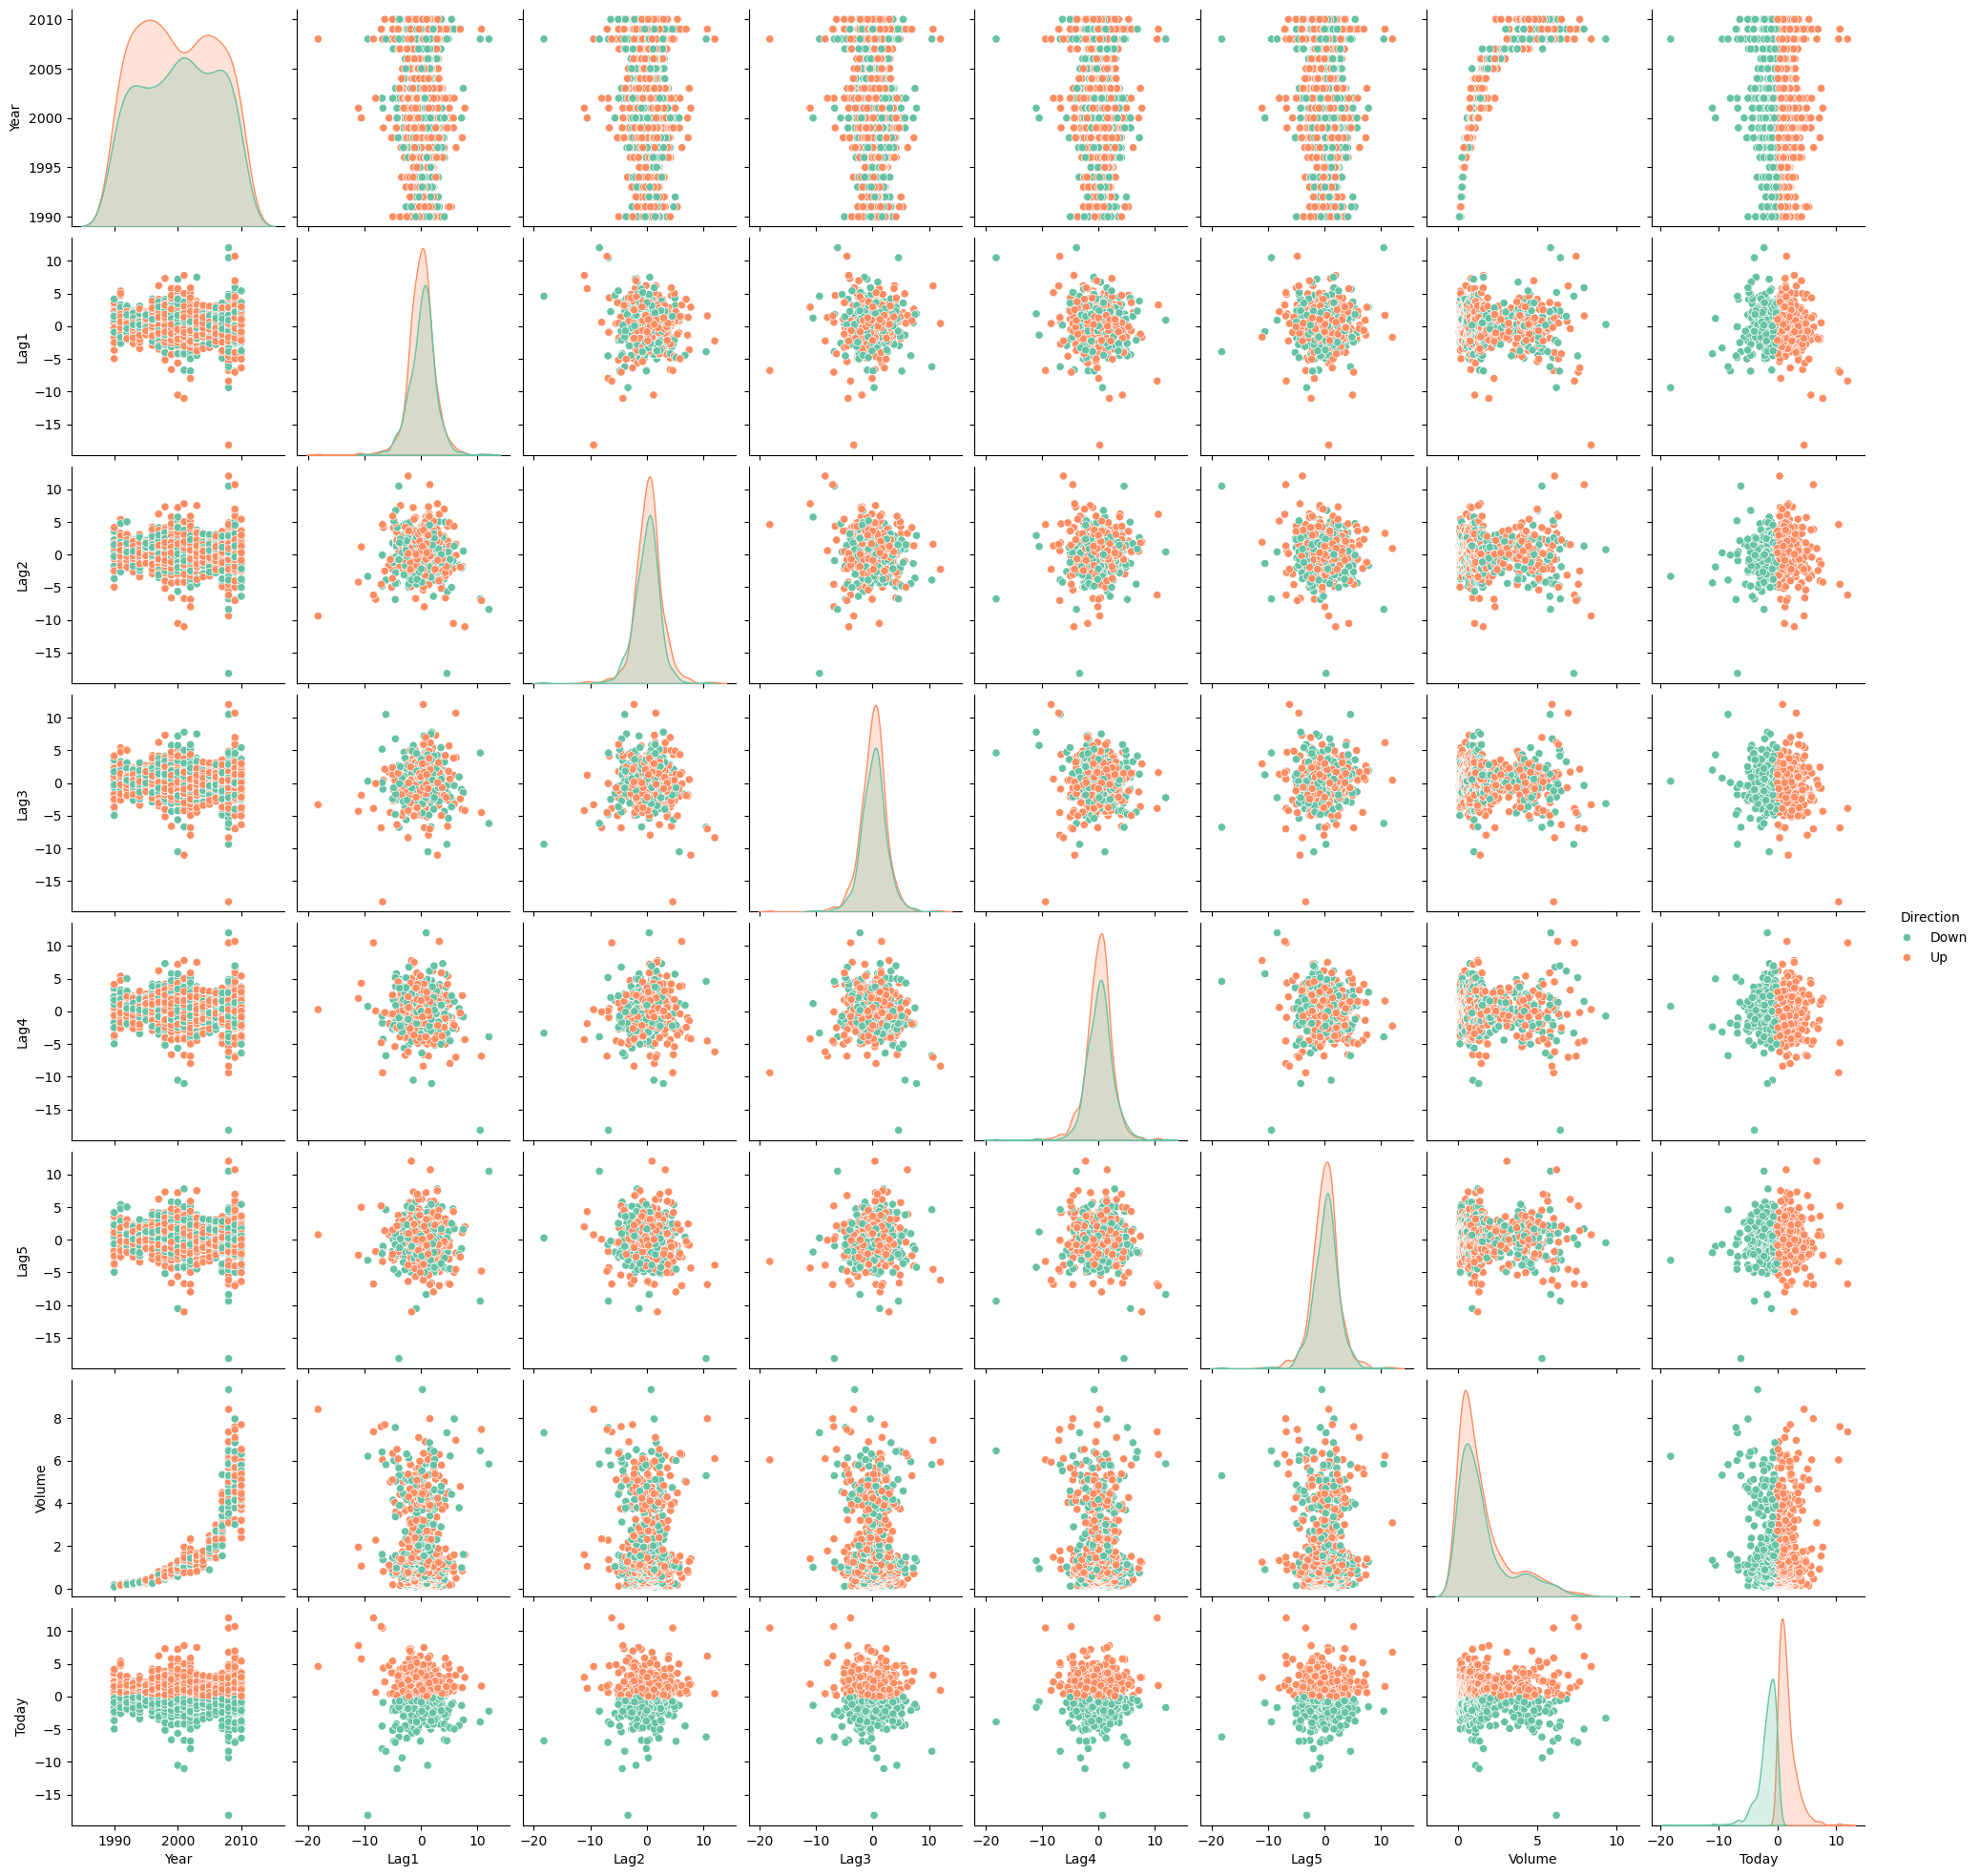

In [230]:
# Pairs plot
sns.pairplot(weekly, hue = 'Direction', palette = 'Set2')
plt.show()

<Axes: xlabel='Year'>

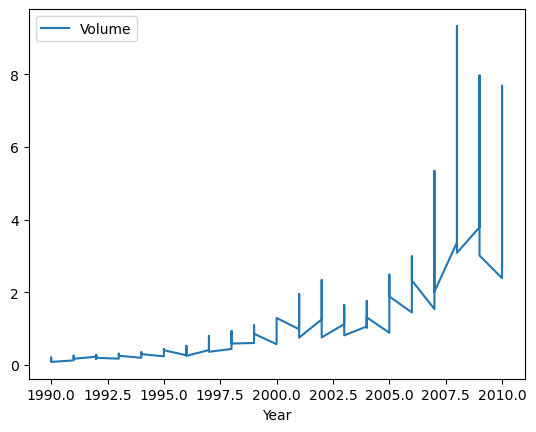

In [231]:
weekly.plot(x = 'Year', y = 'Volume')

### This plot shows that as years go on, volume of trading increases substantially.

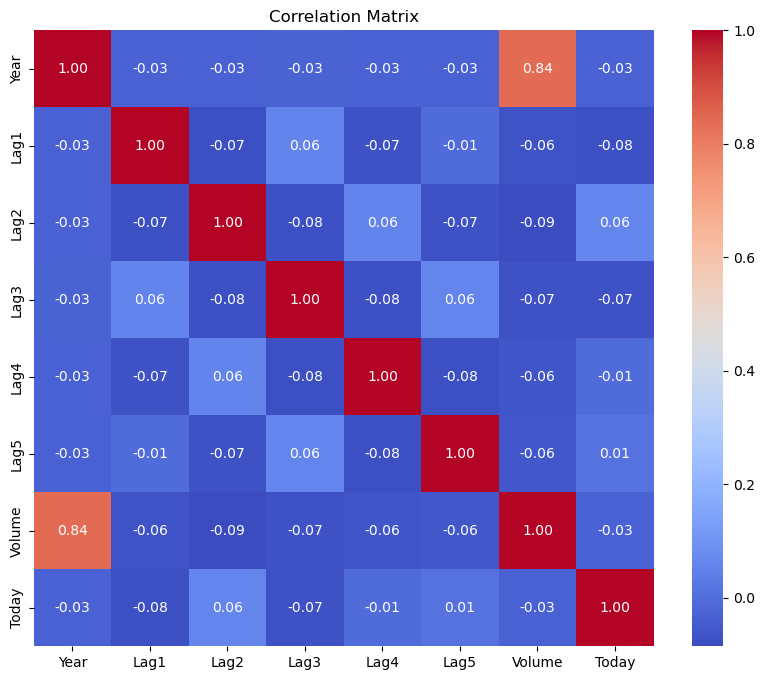

In [232]:
# Correlation matrix
numMatrix = weekly.drop(columns = ['Direction'])
correlation_matrix = numMatrix.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### This correlation matrix shows almost no correlation at all, with most being at zero.  The only significant correlation is that of year and volume.

<Figure size 800x500 with 0 Axes>

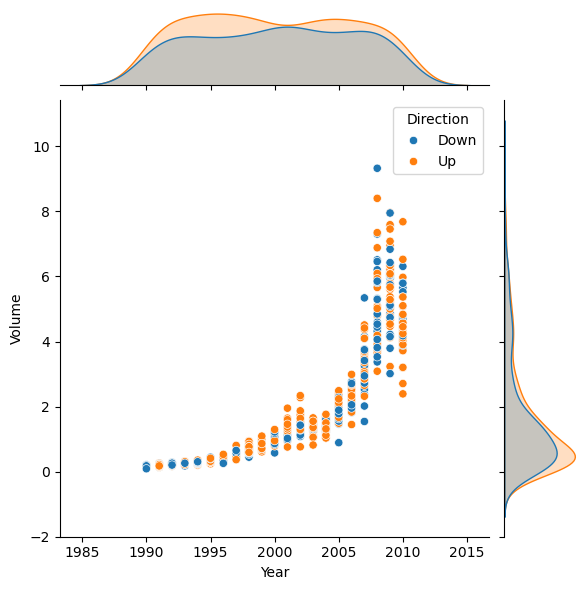

In [233]:
# Year versus volume
plt.figure(figsize = (8,5))
sns.jointplot(x = 'Year', y = 'Volume', hue = 'Direction', data = weekly)
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()

# 4.13b: Logistic Regression

In [234]:
allvars = weekly.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(weekly)
y = weekly.Direction == 'Up'
glm = sm.GLM(y,
            X,
            family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


### The smallest p-value coefficient is Lag2, at 0.030, making it the most accurate predictor, and the coefficient is positive.  Since the Lag2 variable was positive, then the likelihood of going up today is high.

In [235]:
results.params

intercept    0.266864
Lag1        -0.041269
Lag2         0.058442
Lag3        -0.016061
Lag4        -0.027790
Lag5        -0.014472
Volume      -0.022742
dtype: float64

In [236]:
results.pvalues

intercept    0.001899
Lag1         0.118144
Lag2         0.029601
Lag3         0.546924
Lag4         0.293653
Lag5         0.583348
Volume       0.537675
dtype: float64

In [237]:
probs = results.predict()
probs[:20]

array([0.60862494, 0.60103144, 0.58756995, 0.48164156, 0.61690129,
       0.56841902, 0.57860971, 0.51519724, 0.57151998, 0.55542873,
       0.60920965, 0.53701255, 0.51252627, 0.58589837, 0.62486788,
       0.54752151, 0.49936118, 0.59296603, 0.52352412, 0.59140154])

In [238]:
labels = np.array(['Down'] * 1089)
labels[probs > 0.5] = "Up"

# 4.13c Confusion matrix and accuracy of predictions

In [239]:
confusion_table(labels, weekly.Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


### There were several accurate predictions, 54 down and 557 up, for a total of 611 accurate predictions out of a total of 1089 observations.

In [240]:
(54 + 557) / 1089, np.mean(labels == weekly.Direction)

(0.5610651974288338, np.float64(0.5610651974288338))

### This means the training error rate is = (1.00 - 52.11) = 47.89%.

In [241]:
train = (weekly.Year < 2005)
Smarket_train = weekly.loc[train]
Smarket_test = weekly.loc[~train]
Smarket_test.shape

(313, 9)

In [242]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
X_train,
family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [243]:
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [244]:
labels = np.array(['Down'] * 313)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,114,137
Up,27,35


In [245]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.476038338658147), np.float64(0.5239616613418531))

### In this case, accuracy is about 47.6% accurate, with an error rate of ~ 52.4%.

In [246]:
model = MS(['Lag1', 'Lag2']).fit(weekly)
X = model.transform(weekly)
X_train, X_test = X.loc[train], X.loc[~train]
glm_train = sm.GLM(y_train,
                    X_train,
                    family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog = X_test)
labels = np.array(['Down'] * 313)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,8,7
Up,133,165


In [247]:
(8 + 165) / 313, 165 / (165 + 133)

(0.5527156549520766, 0.5536912751677853)

### Additionally, this shows that on days a logistic regression predicts an 'Up', there's a 55.4% accuracy rate

In [248]:
newdata = pd.DataFrame({'Lag1':[1.2, 1.5],
                        'Lag2':[1.1, -0.8]});
newX = model.transform(newdata)
results.predict(newX)

0    0.562003
1    0.536523
dtype: float64

# 4.13.d Additional logistic regression

In [249]:
train = (weekly.Year < 2009)
Smarket_train = weekly.loc[train]
Smarket_test = weekly.loc[~train]
Smarket_test.shape

(104, 9)

In [250]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
X_train,
family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [251]:
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [252]:
labels = np.array(['Down'] * 104)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,7,8
Up,36,53


In [253]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.5769230769230769), np.float64(0.4230769230769231))

In [254]:
model = MS(['Lag2']).fit(weekly)
X = model.transform(weekly)
X_train, X_test = X.loc[train], X.loc[~train]
glm_train = sm.GLM(y_train,
                    X_train,
                    family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog = X_test)
labels = np.array(['Down'] * 104)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [255]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.625), np.float64(0.375))

### In this logistic regression (using only Lag2 with the lowest p-value), there is a 62.5% accuracy rate and a 37.5% error rate.

# 4.13e LDA

In [284]:
train = (weekly.Year < 2005)
Smarket_train = weekly.loc[train]
Smarket_test = weekly.loc[~train]
Smarket_test.shape

(313, 9)

In [285]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
X_train,
family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [286]:
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [287]:
labels = np.array(['Down'] * 313)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,8,7
Up,133,165


In [288]:
model = MS(['Lag2']).fit(weekly)
X = model.transform(weekly)
X_train, X_test = X.loc[train], X.loc[~train]
glm_train = sm.GLM(y_train,
                    X_train,
                    family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog = X_test)
labels = np.array(['Down'] * 313)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,8,7
Up,133,165


In [289]:
lda = LDA(store_covariance = True)

In [290]:
X_train, X_test = [M.drop(columns=['intercept'])
for M in [X_train, X_test]]
lda.fit(X_train, L_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,True
,tol,0.0001
,covariance_estimator,None


In [291]:
lda.means_

array([[0.27440525, 0.05883965],
       [0.12342494, 0.29473441]])

In [292]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [293]:
lda.priors_

array([0.44201031, 0.55798969])

In [294]:
lda.scalings_

array([[-0.23086126],
       [ 0.38956872]])

In [295]:
lda_pred = lda.predict(X_test)

In [296]:
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,8,7
Up,133,165


In [ ]:
### The LDA appears to be as accurate as logistic regression, at 

In [297]:
lda_prob = lda.predict_proba(X_test)
np.all(
    np.where(lda_prob[:,1] >= 0.5, 'Up','Down') == lda_pred
    )

np.True_

In [298]:
np.all(
    [lda.classes_[i] for i in np.argmax(lda_prob, 1)] ==
    lda_pred
    )

np.True_

In [299]:
np.sum(lda_prob[:,0] > 0.9)

np.int64(0)

# 4.13f QDA

In [300]:
qda = QDA(store_covariance = True)
qda.fit(X_train, L_train)

,priors,None
,reg_param,0.0
,store_covariance,True
,tol,0.0001


In [301]:
qda.means_, qda.priors_

(array([[0.27440525, 0.05883965],
        [0.12342494, 0.29473441]]),
 array([0.44201031, 0.55798969]))

In [302]:
qda.covariance_[0]

array([[ 4.25321124, -0.24379687],
       [-0.24379687,  3.67947509]])

In [303]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,24,24
Up,117,148


In [304]:
np.mean(qda_pred == L_test)

np.float64(0.549520766773163)

### Accuracy on this QDA is 58.7%.

# 4.13g Naive Bayes

In [305]:
NB = GaussianNB()
NB.fit(X_train, L_train)

,priors,None
,var_smoothing,1e-09


In [306]:
NB.classes_

array(['Down', 'Up'], dtype='<U4')

In [307]:
NB.class_prior_

array([0.44201031, 0.55798969])

In [308]:
NB.theta_

array([[0.27440525, 0.05883965],
       [0.12342494, 0.29473441]])

In [309]:
NB.var_

array([[4.24081121, 3.66874777],
       [4.83044325, 5.27046953]])

In [310]:
X_train[L_train == 'Down'].mean()

Lag1    0.274405
Lag2    0.058840
dtype: float64

In [311]:
X_train[L_train == 'Down'].var(ddof=0)

Lag1    4.240811
Lag2    3.668748
dtype: float64

In [312]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,Down,Up
Predicted,,
Down,27,29
Up,114,143


In [313]:
(27 + 143)/313

0.5431309904153354

### Naive Bayes model is accurate approximately 54.3% of the time.

In [314]:
NB.predict_proba(X_test)[:12]

array([[0.47309007, 0.52690993],
       [0.46478014, 0.53521986],
       [0.47648663, 0.52351337],
       [0.48375228, 0.51624772],
       [0.49957692, 0.50042308],
       [0.49967633, 0.50032367],
       [0.40369193, 0.59630807],
       [0.49781126, 0.50218874],
       [0.51109272, 0.48890728],
       [0.49429659, 0.50570341],
       [0.45719097, 0.54280903],
       [0.47653282, 0.52346718]])

# 4.13g KNN

In [315]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,Down,Up
Predicted,,
Down,72,73
Up,69,99


In [317]:
(99 + 72)/313, np.mean(knn1_pred == L_test)

(0.5463258785942492, np.float64(0.5463258785942492))

### The KNN classifier is approximately 54.6% accurate.

# 4.13i 

### Logistic regression utilizing only the Lag2 variable (with lowest p-value) appears to be the most accurate, at 62.5%.

# 4.13j

### Utilizing KNN and only Lag2 variable

In [335]:
train = (weekly.Year < 2005)
Smarket_train = weekly.loc[train]
Smarket_test = weekly.loc[~train]
Smarket_test.shape

(313, 9)

In [336]:
knn1 = KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,Down,Up
Predicted,,
Down,54,70
Up,87,102


In [340]:
( 102 + 54) / 313

0.4984025559105431

### The KNN classifier utilizing k = 3 is a bit less accurate (at 49.8%) than the model that utilizes k = 1.